# Masknmf: ASAP7 voltage indicator, single channel

In [41]:
from pathlib import Path

import fastplotlib as fpl
import matplotlib.pyplot as plt
import numpy as np

import mbo_utilities as mbo
import masknmf

In [42]:
MESC_PATH = Path("~/data/asako/ASAP7/GT279-1_spine_signal_zstack.mesc").expanduser()
UNIT = "MUnit_14"
CHANNEL = 0
EXCLUDE_INITIAL_FRAMES = 200
OUTPUT_FOLDER = MESC_PATH.parent / "masknmf_asap7" / UNIT.replace("/", "_")
DEVICE = "cuda"
MAD_CORRELATION_THRESHOLD = 0.6

## Load and invert indicator

In [43]:
arr = mbo.imread(MESC_PATH, unit=UNIT)
fs = arr.metadata["fs"]
raw = arr[EXCLUDE_INITIAL_FRAMES:, CHANNEL, 0]
movie = masknmf.OphysArray(raw, negative_indicator=True, include_mean=True, device="cpu")[:].numpy()
movie.shape

(46312, 18, 39)

## Denoise before registration

tiny movie, tiny block size

In [44]:
block_sizes = [4, 4]
moco_strategy = masknmf.CompressStrategy(block_sizes=block_sizes,
                                         max_components=20,
                                         max_consecutive_failures=1,
                                         temporal_avg_factor=2,
                                         spatial_avg_factor=4,
                                         frame_batch_size=300)
pmd_moco = moco_strategy.compress(movie)
pmd_moco.to(DEVICE)

[26-10-02 13:44:19]: Starting compression
[26-10-02 13:44:19]: sampled from the following regions: [0]
[26-10-02 13:44:19]: We are initializing on a total of 46312 frames
[26-10-02 13:44:19]: Loading data to estimate complete spatial basis
[26-10-02 13:44:19]: skipping the pruning step for frame cutoff
[26-10-02 13:44:19]: Finding spatiotemporal roughness thresholds


100%|██████████| 250/250 [00:01<00:00, 186.91it/s]

[26-10-02 13:44:20]: Running Blockwise Decompositions



100%|██████████| 8/8 [00:02<00:00,  3.62it/s]

[26-10-02 13:44:23]: Constructed spatial_compressed matrix. Rank of spatial_compressed is 152
[26-10-02 13:44:23]: Compression Object constructed


## Register

Shifts are estimated on the denoised movie and applied to the raw frames.

In [45]:
corrector = masknmf.RigidMotionCorrector(max_shifts=[40, 40])
corrector.compute_template(pmd_moco)
moco_array = corrector.motion_correct(reference_movie=pmd_moco, target_movie=movie)

registered = moco_array[:].cpu().numpy()
pmd_registered = corrector.motion_correct(reference_movie=pmd_moco)[:].cpu().numpy()
shifts = moco_array.shifts.cpu().numpy()

100%|██████████| 10/10 [00:00<00:00, 77.58it/s]

[26-10-02 13:44:52]: extracting all shifts from dataset



100%|██████████| 232/232 [00:01<00:00, 137.63it/s]


[26-10-02 13:44:55]: extracting all shifts from dataset


100%|██████████| 232/232 [00:01<00:00, 142.93it/s]


## Compare

In [46]:
panels = {
    "raw": movie,
    "pmd(raw)": pmd_moco,
    "registered": registered,
    "pmd(registered)": pmd_registered,
}
ndw = fpl.NDWidget(names=list(panels), shape=(2, 2), size=(900, 700))
for name, data in panels.items():
    image = ndw[name].add_nd_image(data, ["time", "m", "n"], ["m", "n"], spatial_func=None, name=name)
    image.graphic.cmap = "gray"
ndw.show()

The same registration with no denoising: template and shifts estimated on the raw movie.

In [48]:
corrector_raw = masknmf.RigidMotionCorrector(max_shifts=[40, 40])
corrector_raw.compute_template(movie)
shifts_raw = corrector_raw.motion_correct(movie).shifts.cpu().numpy()

100%|██████████| 10/10 [00:00<00:00, 121.13it/s]

[26-10-02 13:45:22]: extracting all shifts from dataset



100%|██████████| 232/232 [00:01<00:00, 157.91it/s]


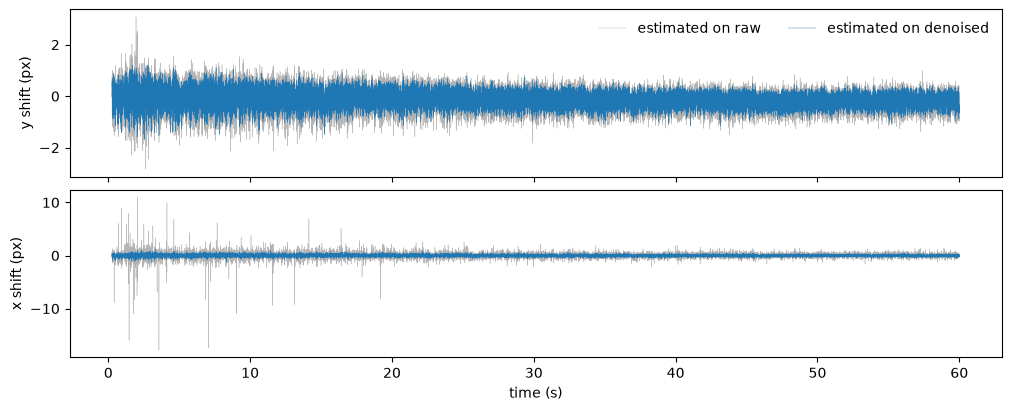

In [49]:
t = (EXCLUDE_INITIAL_FRAMES + np.arange(movie.shape[0])) / fs
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True, layout="constrained")
for ax, k, label in zip(axes, (0, 1), ("y shift (px)", "x shift (px)")):
    ax.plot(t, shifts_raw[:, k], lw=0.3, color="0.7", label="estimated on raw")
    ax.plot(t, shifts[:, k], lw=0.3, color="C0", label="estimated on denoised")
    ax.set_ylabel(label)
axes[0].legend(loc="upper right", ncols=2, frameon=False)
axes[1].set_xlabel("time (s)")
plt.show()

## Pipeline

`mad_correlation_threshold` decreased to  0.6 instead of 0.8 where no signals are found

In [50]:
passes = []
for _ in range(2):
    init_config = masknmf.SuperpixelInitConfig(mad_correlation_threshold=MAD_CORRELATION_THRESHOLD,
                                               residual_threshold=0.1,
                                               sign="positive")
    nmf_config = masknmf.NMFConfig(support_threshold=(0.95, 0.7),
                                   ring_model_start_pt=41,
                                   min_brightness=0.0,
                                   merge_threshold=0.7,
                                   reassign_background=False)
    passes.append(masknmf.SinglepassDemixingConfig(init_config, nmf_config))
demixing_config = masknmf.MultipassDemixingConfig(passes)

In [51]:
pipeline = masknmf.GlutamateCalciumSpinePipeline(output_folder=OUTPUT_FOLDER,
                                                 demixing_config=demixing_config,
                                                 device=DEVICE)
run_folder = pipeline.run(glutamate_channel=movie,
                          calcium_channel=None,
                          exclude_initial_frames=0)
run_folder

[26-10-02 13:45:37]: masknmf 0.1.0 GlutamateCalciumSpinePipeline on cuda, info log at C:\Users\loson\data\asako\ASAP7\masknmf_asap7\MUnit_14\20261002_134537_glutamate-calcium-spine\20261002_134537_glutamate-calcium-spine.log
[26-10-02 13:45:37]: Writing results to C:\Users\loson\data\asako\ASAP7\masknmf_asap7\MUnit_14\20261002_134537_glutamate-calcium-spine
[26-10-02 13:45:37]: reference compression
[26-10-02 13:45:37]: Starting compression
[26-10-02 13:45:37]: sampled from the following regions: [0]
[26-10-02 13:45:37]: We are initializing on a total of 46312 frames
[26-10-02 13:45:37]: Loading data to estimate complete spatial basis
[26-10-02 13:45:37]: skipping the pruning step for frame cutoff
[26-10-02 13:45:37]: Finding spatiotemporal roughness thresholds


100%|██████████| 250/250 [00:01<00:00, 157.73it/s]

[26-10-02 13:45:39]: Running Blockwise Decompositions



100%|██████████| 3/3 [00:00<00:00,  5.17it/s]

[26-10-02 13:45:39]: Constructed spatial_compressed matrix. Rank of spatial_compressed is 33
[26-10-02 13:45:39]: Compression Object constructed
[26-10-02 13:45:39]: reference compression done in 0:00:02, peak cuda 0.27 GB


...

[26-10-02 13:47:20]: 4 signals
[26-10-02 13:47:20]: glutamate spine demixing pass 1 of 2 done in 0:00:01, peak cuda 0.46 GB
[26-10-02 13:47:20]: glutamate spine demixing pass 2 of 2
[26-10-02 13:47:20]: Computing correlation data structure with MAD threshold  1


[26-10-02 13:47:20]:  peaks shape is torch.Size([0, 2])
[26-10-02 13:47:20]: No superpixels found, set lower correlation threshold!
[26-10-02 13:47:20]: no signals detected, keeping the previous pass
[26-10-02 13:47:20]: glutamate spine demixing pass 2 of 2 done in 0:00:00, peak cuda 0.23 GB
[26-10-02 13:47:20]: baseline is 0.0
[26-10-02 13:47:20]: glutamate whole-dendrite demixing
[26-10-02 13:47:20]: no temporal footprints provided, running nonneg least squares
[26-10-02 13:47:20]: started with 1 signals, ended initialization with 1 signals
[26-10-02 13:47:20]: baseline is 0.0


100%|██████████| 40/40 [00:00<00:00, 194.19it/s]


[26-10-02 13:47:20]: glutamate whole-dendrite demixing done in 0:00:00, peak cuda 0.46 GB
[26-10-02 13:47:20]: glutamate raw traces
[26-10-02 13:47:30]: glutamate raw traces done in 0:00:10, peak cuda 0.22 GB


WindowsPath('C:/Users/loson/data/asako/ASAP7/masknmf_asap7/MUnit_14/20261002_134537_glutamate-calcium-spine')

## Results

To reopen an earlier run, set `run_folder` to it and skip the run cell.

In [53]:
results_path = run_folder / "results.glutamate.hdf5"
spines = masknmf.DemixingResults.from_hdf5(results_path, device=DEVICE)
dendrite = masknmf.DemixingResults.from_hdf5(results_path, prefix="global", device=DEVICE)
spines.spatial_demixed.shape, dendrite.spatial_demixed.shape

(torch.Size([702, 4]), torch.Size([702, 1]))

In [54]:
vis = masknmf.SingleSessionDemixingVis(spines,
                                       frame_timings=t,
                                       results_path=results_path,
                                       raw=movie,
                                       device=DEVICE)
vis.show()

[26-10-02 13:48:35]: cell stats: mean, std, snr, skew, fit, resid, bkgd; right-click a Signals table header to show them
[26-10-02 13:48:35]: raw panel: movie given
[26-10-02 13:48:35]: shift traces: C:\Users\loson\data\asako\ASAP7\masknmf_asap7\MUnit_14\20261002_134537_glutamate-calcium-spine\results.glutamate.hdf5
